In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use('default')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [3]:
telemetry = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/telemetry.csv")
assets = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/asset_metadata.csv")
connectivity = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/connectivity.csv")

print("Telemetry Shape:", telemetry.shape)
print("Assets Shape:", assets.shape)
print("Connectivity Shape:", connectivity.shape)

Telemetry Shape: (60480, 12)
Assets Shape: (42, 8)
Connectivity Shape: (36, 4)


In [4]:
telemetry.head()

,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2025-01-01 00:00:00,S1,B1,B1_CH_01,15.12,66.41,101.40,0.65,29.42,4,Cooling,0
1,2025-01-01 01:00:00,S1,B1,B1_CH_01,18.19,62.37,100.86,0.89,31.46,10,Cooling,0
2,2025-01-01 02:00:00,S1,B1,B1_CH_01,20.17,61.50,101.61,0.32,27.67,8,Idle,0
3,2025-01-01 03:00:00,S1,B1,B1_CH_01,20.87,38.54,101.56,0.89,27.35,11,Idle,0
4,2025-01-01 04:00:00,S1,B1,B1_CH_01,17.63,56.71,101.79,1.27,28.42,0,Idle,0


In [5]:
assets.head()

,asset_id,site_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id
0,B1_CH_01,S1,B1_CH_01,Chiller,Schneider,2021-01-01,500,NaN
1,B1_AHU_01,S1,B1_AHU_01,AHU,JohnsonControls,2022-01-01,150,B1_CH_01
2,B1_AHU_01_SEN,S1,B1_AHU_01_SEN,Sensor,Siemens,2023-01-01,10,B1_AHU_01
3,B1_AHU_02,S1,B1_AHU_02,AHU,Schneider,2022-01-01,150,B1_CH_01
4,B1_AHU_02_SEN,S1,B1_AHU_02_SEN,Sensor,Schneider,2023-01-01,10,B1_AHU_02


In [6]:
connectivity.head()

,source_asset_id,target_asset_id,connection_type,relationship_strength
0,B1_CH_01,B1_AHU_01,Supplies,0.90
1,B1_AHU_01,B1_AHU_01_SEN,Monitors,0.80
2,B1_CH_01,B1_AHU_02,Supplies,0.90
3,B1_AHU_02,B1_AHU_02_SEN,Monitors,0.80
4,B1_CH_01,B1_PUMP_01,Controls,0.85


In [7]:
telemetry.info()

<class 'pandas.DataFrame'>
RangeIndex: 60480 entries, 0 to 60479
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          60480 non-null  str    
 1   site_id            60480 non-null  str    
 2   building_id        60480 non-null  str    
 3   asset_id           60480 non-null  str    
 4   temperature        60480 non-null  float64
 5   humidity           60480 non-null  float64
 6   pressure           60480 non-null  float64
 7   vibration          60480 non-null  float64
 8   power_consumption  60480 non-null  float64
 9   occupancy_count    60480 non-null  int64  
 10  operating_mode     60480 non-null  str    
 11  fault_flag         60480 non-null  int64  
dtypes: float64(5), int64(2), str(5)
memory usage: 5.5 MB


In [8]:
assets.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   asset_id           42 non-null     str  
 1   site_id            42 non-null     str  
 2   asset_name         42 non-null     str  
 3   asset_type         42 non-null     str  
 4   manufacturer       42 non-null     str  
 5   installation_date  42 non-null     str  
 6   capacity           42 non-null     int64
 7   parent_asset_id    36 non-null     str  
dtypes: int64(1), str(7)
memory usage: 2.8 KB


In [9]:
connectivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source_asset_id        36 non-null     str    
 1   target_asset_id        36 non-null     str    
 2   connection_type        36 non-null     str    
 3   relationship_strength  36 non-null     float64
dtypes: float64(1), str(3)
memory usage: 1.3 KB


In [10]:
telemetry["timestamp"] = pd.to_datetime(
    telemetry["timestamp"]
)

telemetry["date"] = telemetry["timestamp"].dt.date
telemetry["hour"] = telemetry["timestamp"].dt.hour

telemetry.head()

,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag,date,hour
0,2025-01-01 00:00:00,S1,B1,B1_CH_01,15.12,66.41,101.40,0.65,29.42,4,Cooling,0,2025-01-01,0
1,2025-01-01 01:00:00,S1,B1,B1_CH_01,18.19,62.37,100.86,0.89,31.46,10,Cooling,0,2025-01-01,1
2,2025-01-01 02:00:00,S1,B1,B1_CH_01,20.17,61.50,101.61,0.32,27.67,8,Idle,0,2025-01-01,2
3,2025-01-01 03:00:00,S1,B1,B1_CH_01,20.87,38.54,101.56,0.89,27.35,11,Idle,0,2025-01-01,3
4,2025-01-01 04:00:00,S1,B1,B1_CH_01,17.63,56.71,101.79,1.27,28.42,0,Idle,0,2025-01-01,4


In [11]:
missing = telemetry.isnull().sum()

missing.sort_values(ascending=False)

timestamp            0
site_id              0
building_id          0
asset_id             0
temperature          0
humidity             0
pressure             0
vibration            0
power_consumption    0
occupancy_count      0
operating_mode       0
fault_flag           0
date                 0
hour                 0
dtype: int64

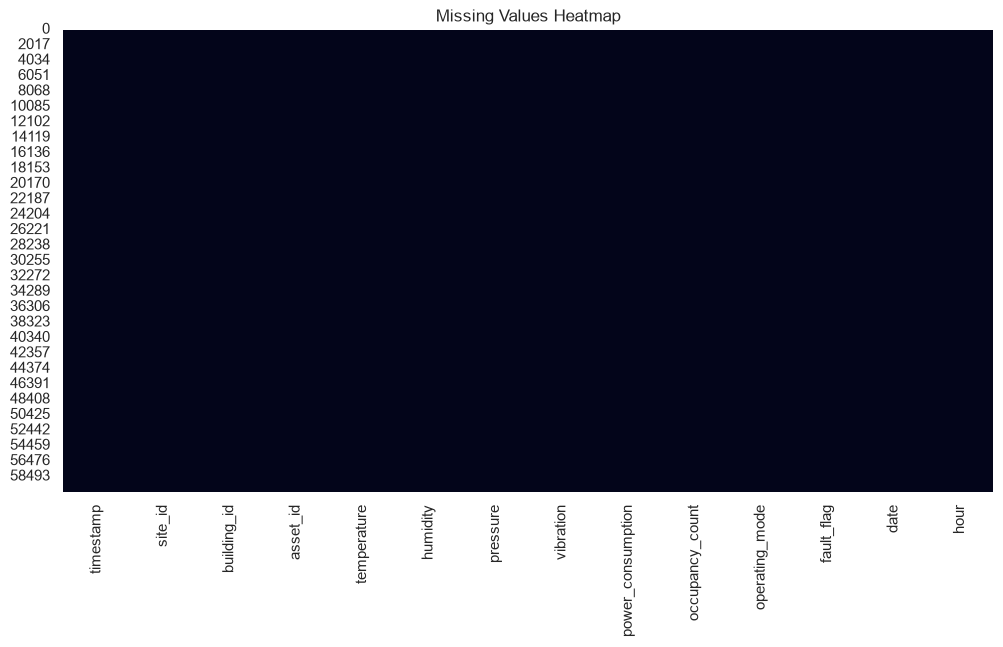

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(
    telemetry.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [13]:
duplicates = telemetry.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [14]:
telemetry.describe()

,timestamp,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,fault_flag,hour
count,60480,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000,60480.000000
mean,2025-01-30 23:30:00,23.215196,55.013065,101.296539,1.500727,49.729554,28.058879,0.013426,11.500000
min,2025-01-01 00:00:00,10.820000,35.000000,94.600000,0.000000,0.760000,0.000000,0.000000,0.000000
25%,2025-01-15 23:45:00,20.440000,45.080000,100.280000,1.090000,27.820000,9.000000,0.000000,5.750000
50%,2025-01-30 23:30:00,23.190000,55.060000,101.300000,1.500000,53.330000,21.000000,0.000000,11.500000
75%,2025-02-14 23:15:00,25.980000,64.940000,102.310000,1.900000,71.590000,48.000000,0.000000,17.250000
max,2025-03-01 23:00:00,35.010000,75.000000,107.600000,4.080000,94.050000,79.000000,1.000000,23.000000
std,NaN,3.633611,11.523096,1.499492,0.592730,23.510495,21.070644,0.115091,6.922244


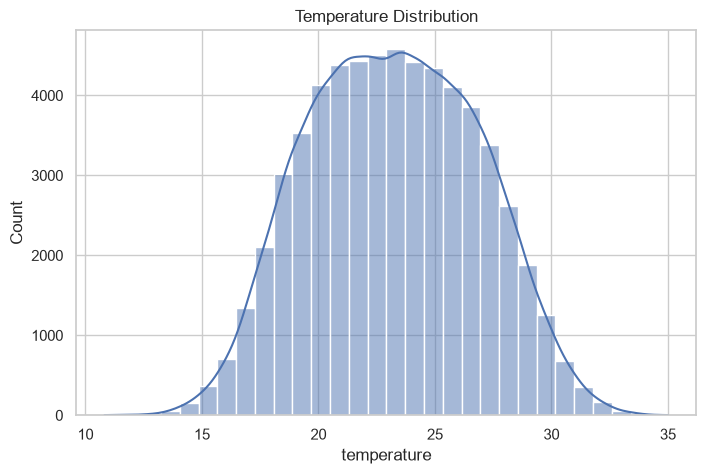

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    telemetry["temperature"],
    bins=30,
    kde=True
)

plt.title("Temperature Distribution")
plt.show()

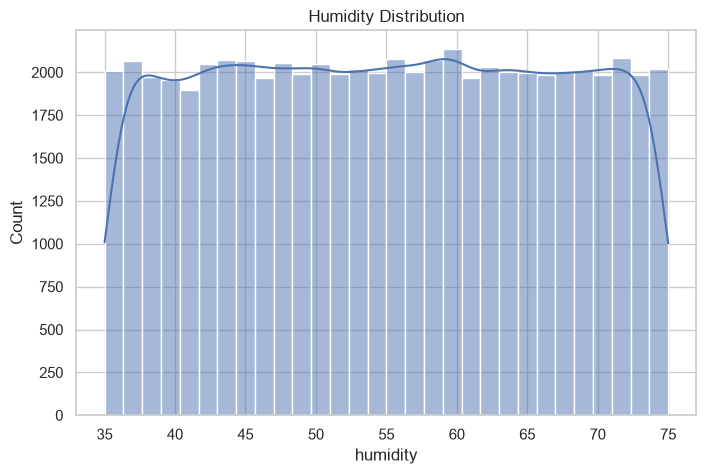

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    telemetry["humidity"],
    bins=30,
    kde=True
)

plt.title("Humidity Distribution")
plt.show()

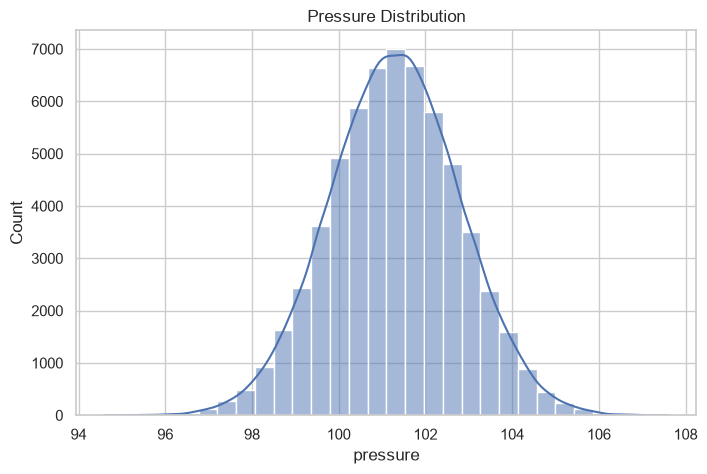

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    telemetry["pressure"],
    bins=30,
    kde=True
)

plt.title("Pressure Distribution")
plt.show()

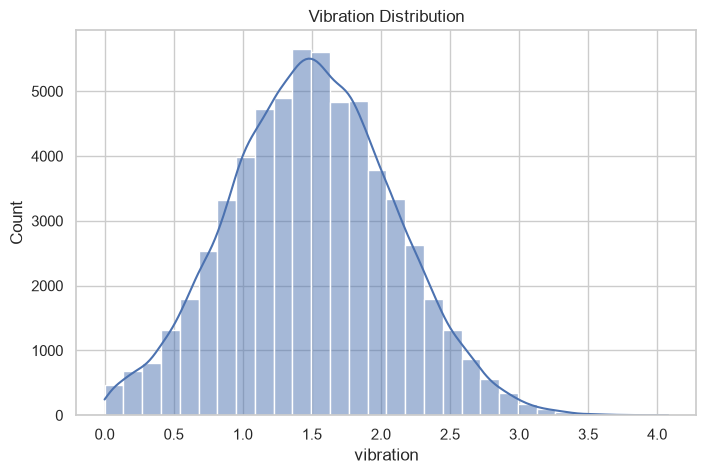

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    telemetry["vibration"],
    bins=30,
    kde=True
)

plt.title("Vibration Distribution")
plt.show()

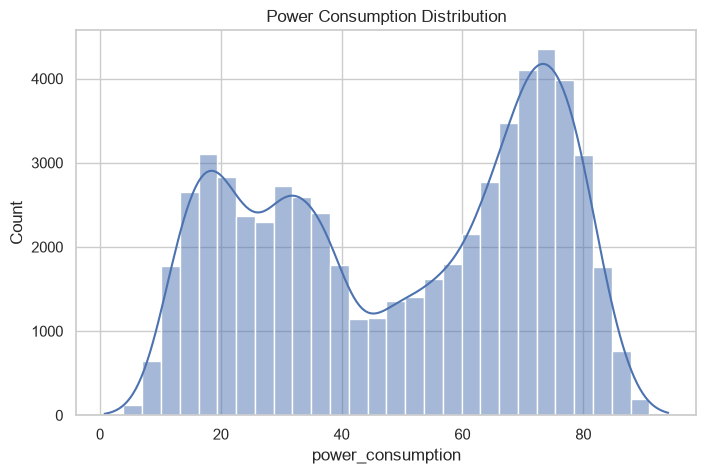

In [20]:
#power consumption distribution
plt.figure(figsize=(8,5))

sns.histplot(
    telemetry["power_consumption"],
    bins=30,
    kde=True
)

plt.title("Power Consumption Distribution")

plt.show()

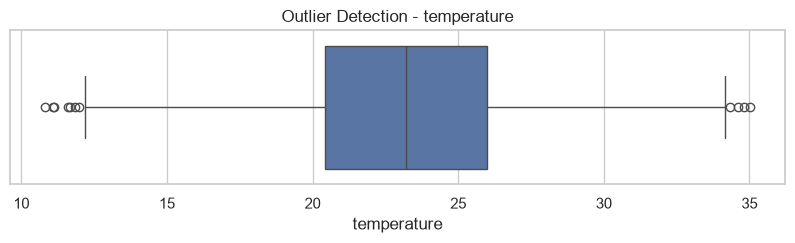

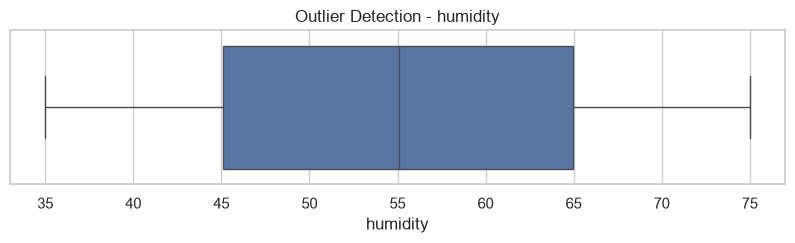

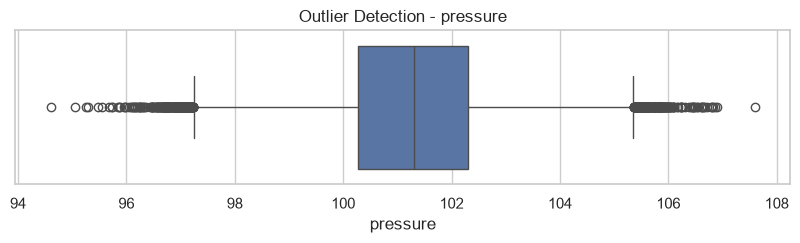

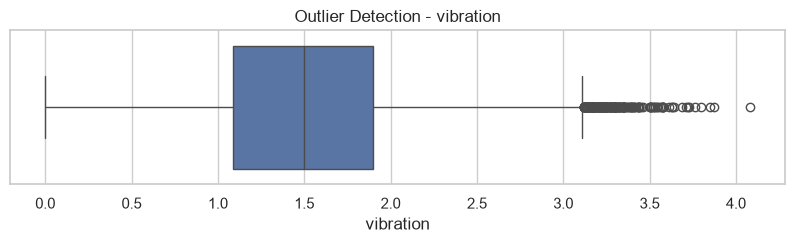

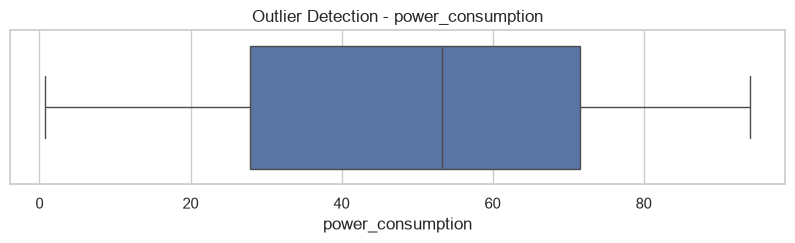

In [21]:
columns = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption"
]

for col in columns:

    plt.figure(figsize=(10,2))

    sns.boxplot(x=telemetry[col])

    plt.title(f"Outlier Detection - {col}")

    plt.show()

In [22]:
#site wise energy consumption
site_energy = (
    telemetry
    .groupby("site_id")["power_consumption"]
    .sum()
    .reset_index()
)

site_energy

,site_id,power_consumption
0,S1,1052899.24
1,S2,1016650.86
2,S3,938093.34


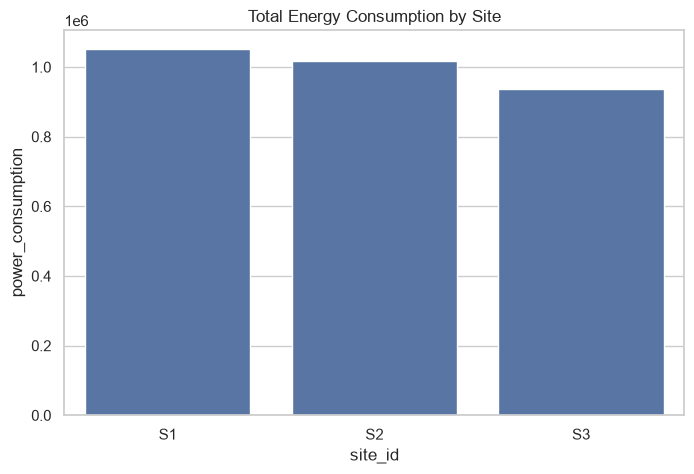

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=site_energy,
    x="site_id",
    y="power_consumption"
)

plt.title("Total Energy Consumption by Site")

plt.show()

In [24]:
#building wise energy consumption
building_energy = (
    telemetry
    .groupby("building_id")["power_consumption"]
    .sum()
    .sort_values(ascending=False)
)

building_energy


building_id
B3    534534.84
B1    528736.31
B2    524162.93
B4    482116.02
B5    479574.54
B6    458518.80
Name: power_consumption, dtype: float64

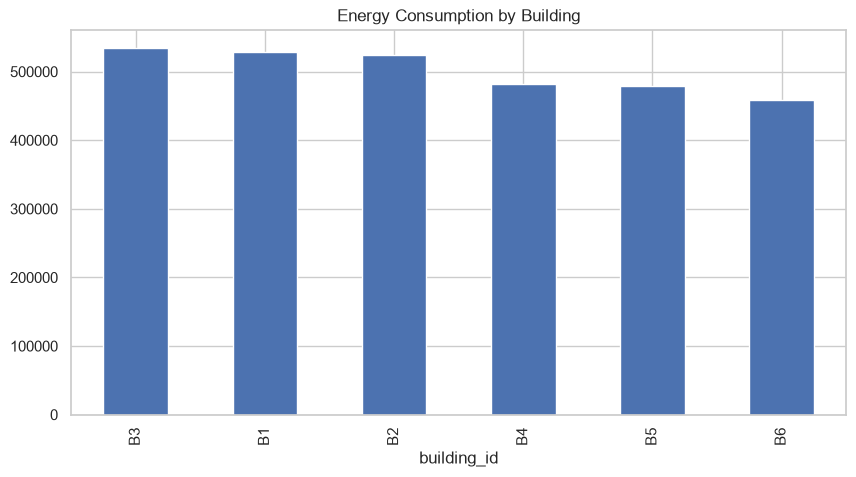

In [25]:
building_energy.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Energy Consumption by Building")

plt.show()



In [26]:
#daily energy trend
daily_energy = (
    telemetry
    .groupby("date")["power_consumption"]
    .sum()
)

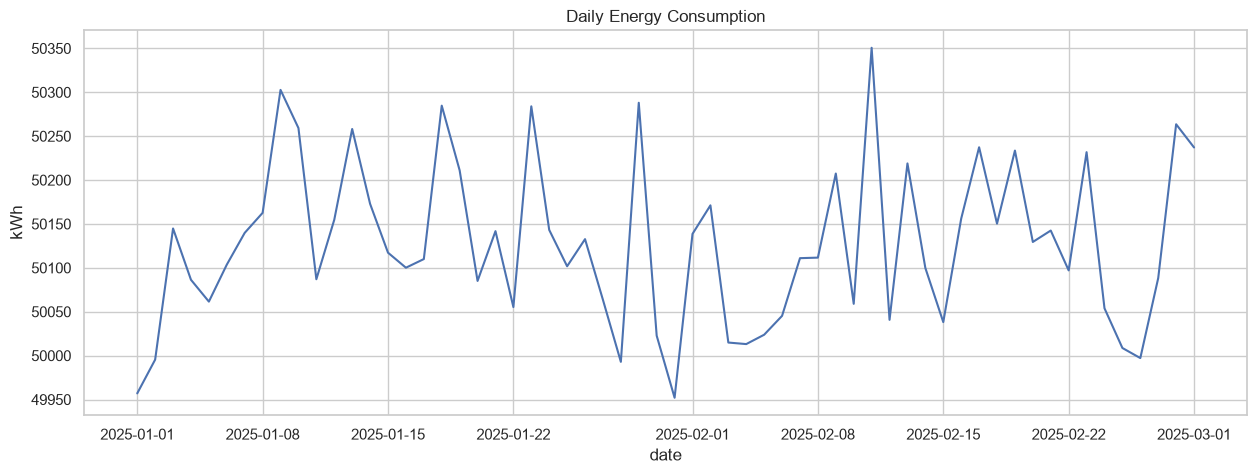

In [27]:
plt.figure(figsize=(15,5))

daily_energy.plot()

plt.title("Daily Energy Consumption")

plt.ylabel("kWh")

plt.show()

In [28]:
#hourly energy trend
hourly_energy = (
    telemetry
    .groupby("hour")["power_consumption"]
    .mean()
)

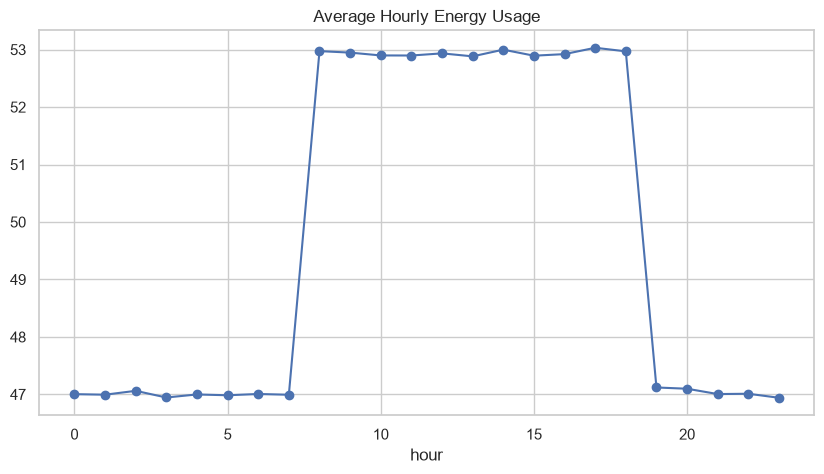

In [29]:
plt.figure(figsize=(10,5))

hourly_energy.plot(
    marker='o'
)

plt.title("Average Hourly Energy Usage")

plt.show()

In [30]:
#fault analysis
telemetry["fault_flag"].value_counts()

fault_flag
0    59668
1      812
Name: count, dtype: int64

In [31]:
fault_analysis = (

    telemetry

    .groupby("fault_flag")

    [[
        "temperature",
        "humidity",
        "pressure",
        "vibration",
        "power_consumption"
    ]]

    .mean()
)
fault_analysis

,temperature,humidity,pressure,vibration,power_consumption
fault_flag,,,,,
0,23.204234,55.004694,101.296182,1.497650,49.730856
1,24.020727,55.628202,101.322746,1.726823,49.633916


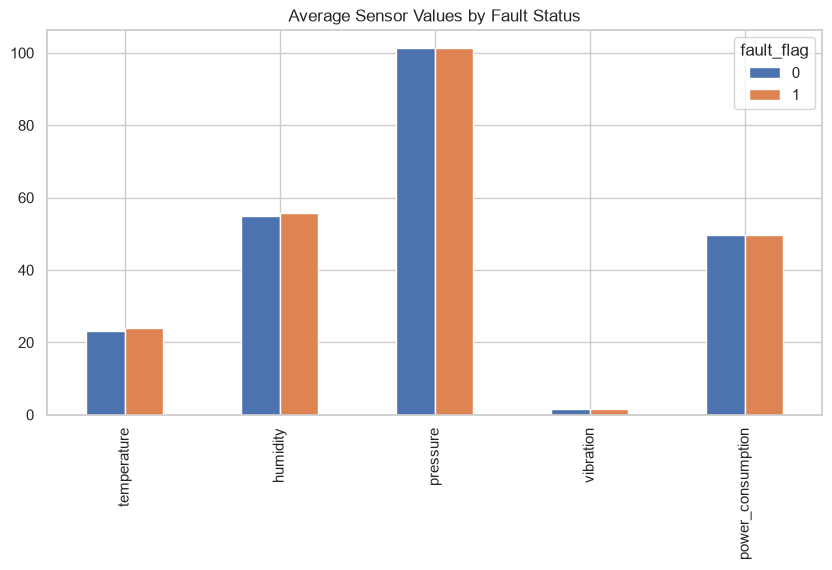

In [32]:
fault_analysis.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Average Sensor Values by Fault Status"
)

plt.show()

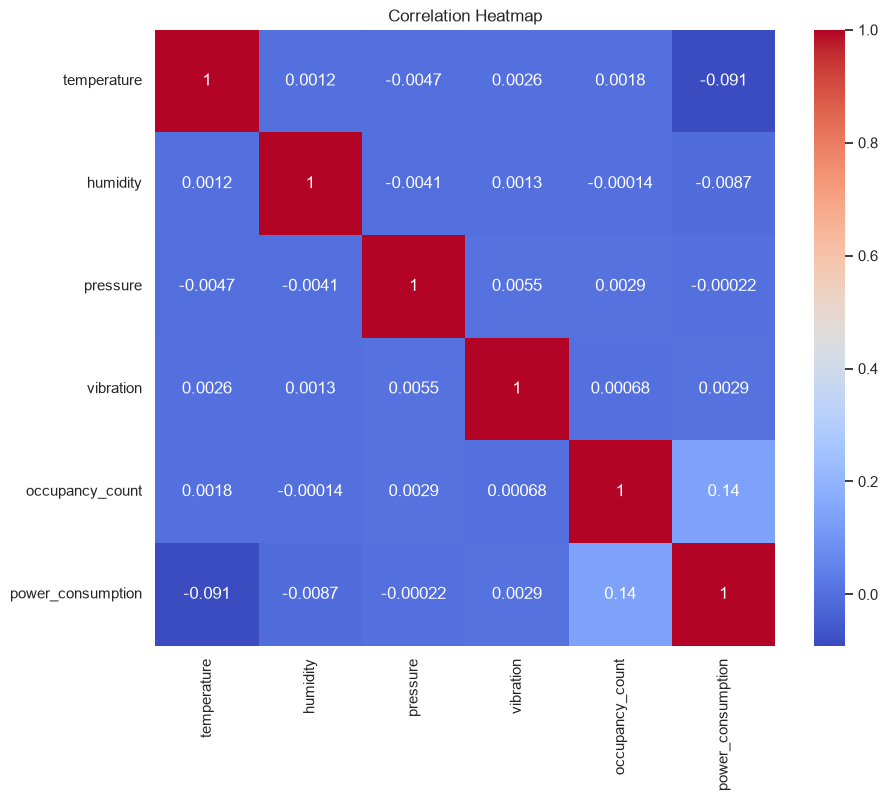

In [33]:
#correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(

    telemetry[
        [
            "temperature",
            "humidity",
            "pressure",
            "vibration",
            "occupancy_count",
            "power_consumption"
        ]
    ].corr(),

    annot=True,
    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

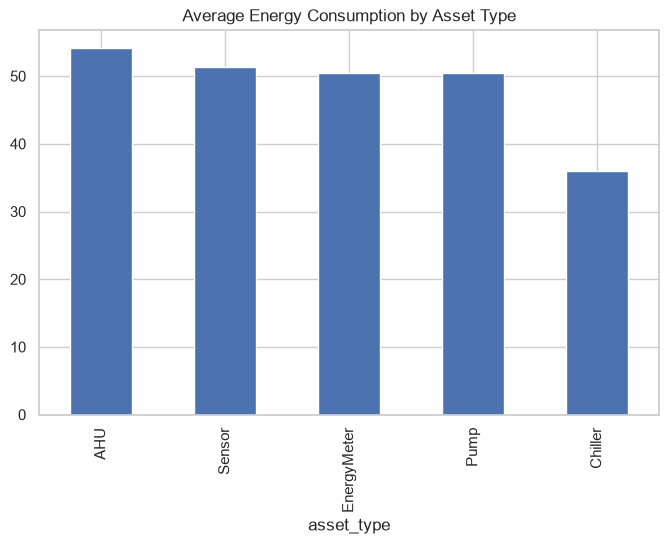

In [34]:
#assest type comparision
merged = telemetry.merge(
    assets,
    on=["asset_id","site_id"],
    how="left"
)

asset_energy = (
    merged
    .groupby("asset_type")["power_consumption"]
    .mean()
    .sort_values(ascending=False)
)

asset_energy.plot(kind="bar", figsize=(8,5))
plt.title("Average Energy Consumption by Asset Type")
plt.show()

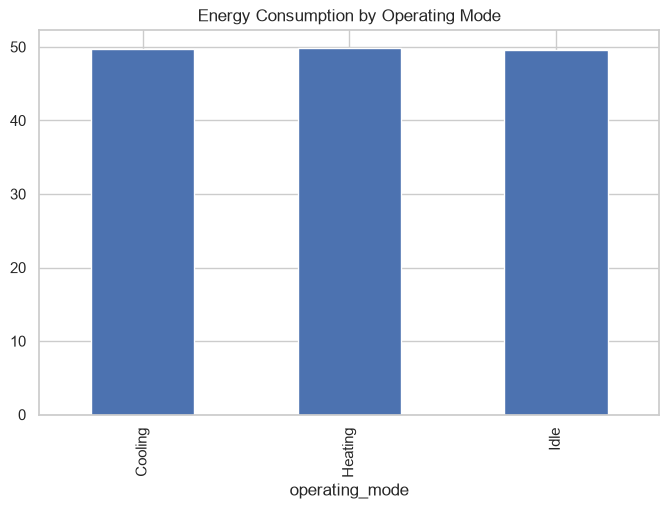

In [35]:
#operation mode analysis
mode_energy = (
    telemetry
    .groupby("operating_mode")["power_consumption"]
    .mean()
)

mode_energy.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Energy Consumption by Operating Mode")
plt.show()

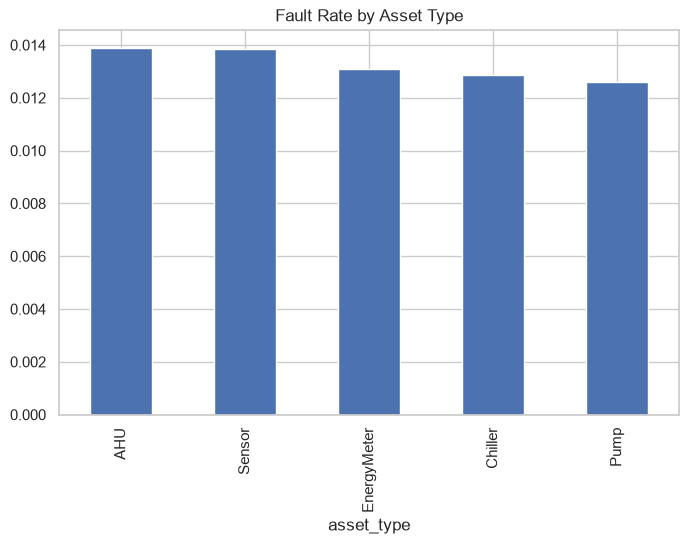

In [36]:
#fault rate by assest type
fault_asset = (
    merged
    .groupby("asset_type")["fault_flag"]
    .mean()
    .sort_values(ascending=False)
)

fault_asset.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fault Rate by Asset Type")
plt.show()

summary

The objective of the exploratory data analysis was to understand the characteristics of the IoT telemetry data, assess data quality, identify operational patterns, analyze energy consumption behavior, and investigate factors contributing to equipment failures.

 1. Data Quality Assessment
- The dataset contained telemetry information from multiple sites, buildings, and interconnected assets.
- Data types and timestamp formats were validated.
- No major data quality issues were identified in the synthetic dataset.

 2. Sensor Distribution Analysis
- Temperature, humidity, pressure, vibration, and power consumption distributions were analyzed.
- Most sensor readings followed expected operational ranges.
- Vibration values exhibited an approximately normal distribution centered around typical operating conditions.

 3. Outlier Analysis
- Boxplot analysis identified a small number of extreme observations in certain sensor measurements.
- These observations may represent abnormal operating conditions or potential equipment issues and should be investigated further.

 4. Site and Building Performance
- Energy consumption varied across sites and buildings.
- Site S1 recorded the highest overall energy consumption, followed by S2 and S3.
- Differences in energy usage indicate varying operational loads and utilization patterns across facilities.

 5. Temporal Patterns
- Daily and hourly energy consumption trends revealed predictable operational behavior.
- Energy demand fluctuated throughout the day, reflecting occupancy and equipment usage patterns.

 6. Fault Analysis
- Assets associated with fault events generally showed higher vibration and temperature levels compared to normal operating conditions.
- This suggests that vibration and temperature are important indicators of equipment health and potential failure.

 7. Energy Consumption Drivers
- Correlation analysis indicated a positive relationship between occupancy levels and power consumption.
- Higher occupancy typically resulted in increased energy demand due to greater HVAC and facility usage.

 8. Asset Type Analysis
- Different asset categories exhibited varying energy consumption patterns.
- Certain asset types consumed significantly more energy than others and may represent key optimization opportunities.

 9. Operating Mode Analysis
- Energy consumption varied across operating modes.
- Cooling operations generally demonstrated higher energy demand compared to idle conditions.

 10. Fault Rate by Asset Type
- Fault occurrence differed across asset categories.
- Assets with higher fault rates should be prioritized for preventive maintenance and condition monitoring.




1. Vibration is a strong leading indicator of equipment degradation and potential failure.

2. Temperature increases often coincide with elevated fault occurrences, making it a valuable predictive maintenance feature.

3. Occupancy levels significantly influence overall energy consumption and should be considered in energy forecasting models.

4. High energy consuming assets present opportunities for operational optimization and cost reduction.

5. Site level energy monitoring can help identify inefficient facilities and support targeted energy saving initiatives.

6. Asset specific maintenance strategies can be developed using historical telemetry patterns and fault behavior.

7. Continuous monitoring combined with predictive analytics can reduce unplanned downtime and improve operational reliability.

conclusion
The exploratory analysis provided valuable insights into equipment behavior, energy consumption patterns, and failure characteristics. These findings will be leveraged in subsequent stages, including predictive maintenance modeling, energy consumption forecasting, anomaly detection, and asset connectivity analysis.